<a href="https://colab.research.google.com/github/VakeesanM/DL-Learning-Deliverables/blob/main/Week%208%20-%20VAEs/Variational_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
class VAE(nn.Module):
  def __init__(self, input_size, latent_dim,hidden_state=200):
    super(VAE, self).__init__()

    self.encoding = nn.Linear(in_features=input_size, out_features=hidden_state)
    self.mu = nn.Linear(in_features=hidden_state, out_features=latent_dim)
    self.sd = nn.Linear(in_features=hidden_state, out_features=latent_dim)


    self.latent_to_hidden = nn.Linear(in_features=latent_dim, out_features=hidden_state)
    self.decoding = nn.Linear(in_features=hidden_state, out_features=input_size)
    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()
  def encode(self, x):
    latent = self.relu(self.encoding(x))
    mean, standard_dev = self.mu(latent), self.sd(latent)
    return mean, standard_dev
  def decode(self, x):
     x = self.latent_to_hidden(x)
     return self.sigmoid(self.decoding(x))
  def forward(self, x: torch.tensor) -> torch.tensor:
    mean, standard_dev = self.encode(x)
    eplision = torch.rand_like(mean)
    z = mean + eplision * standard_dev
    x = self.decode(z)
    return x, mean, standard_dev


In [3]:
vae = VAE(784, 20)
vae(torch.rand(size=(2, 784)))

(tensor([[0.4970, 0.4846, 0.5367,  ..., 0.5023, 0.4903, 0.5536],
         [0.5106, 0.4957, 0.5388,  ..., 0.5015, 0.4898, 0.5487]],
        grad_fn=<SigmoidBackward0>),
 tensor([[ 0.0585, -0.0689, -0.0940,  0.0919,  0.1031,  0.2828,  0.2000,  0.1075,
          -0.1093, -0.0483,  0.1224,  0.1254,  0.0192, -0.0665, -0.0184,  0.1945,
           0.0761,  0.2922,  0.0967, -0.2052],
         [ 0.1127, -0.0593, -0.0410, -0.0022, -0.1155,  0.3079,  0.0987,  0.1671,
          -0.1247, -0.0331,  0.1312,  0.1800,  0.0358, -0.1465,  0.0079,  0.1540,
           0.0473,  0.3102,  0.0576, -0.1715]], grad_fn=<AddmmBackward0>),
 tensor([[ 0.0906, -0.0485,  0.1417,  0.0529, -0.1451,  0.2230,  0.1458,  0.0648,
           0.0404,  0.2432,  0.2437,  0.1739, -0.2190,  0.2209,  0.1190, -0.1780,
          -0.1507,  0.0480,  0.1434,  0.3902],
         [ 0.1138,  0.1213,  0.1075, -0.0065, -0.0657,  0.2294,  0.0966,  0.0975,
           0.0678,  0.3230,  0.2134,  0.1629, -0.2597,  0.2480,  0.1236, -0.1338,
       

In [27]:
from torch.utils.data import DataLoader
from torchvision import transforms
import torchvision.datasets as datasets
import time

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cuda'

In [6]:
dataset = datasets.MNIST(root="dataset/", train=True, transform=transforms.ToTensor(), download=True)
len(dataset)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


60000

In [7]:
data_loader = DataLoader(dataset, shuffle=True, batch_size=50)
len(data_loader)

1200

In [37]:
vae = VAE(784, 500, 40).to(DEVICE)
loss_fn = nn.BCELoss(reduce='sum')
optim = torch.optim.Adam(vae.parameters(), lr=0.0001)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


In [38]:
start = time.time()

EPOCH =  10
loss_list = []
for i in range(EPOCH):
  vae.train()
  total_loss = 0
  for _, (X, _) in enumerate(data_loader):
    X = X.to(DEVICE).view(X.shape[0], 784)
    decoded, mu, sigma = vae(X)

    loss = loss_fn(decoded, X)
    kl_dv = -torch.sum(1+torch.log(sigma.pow(2)) - mu.pow(2) - sigma.pow(2))
    loss += kl_dv
    total_loss = loss.item()
    optim.zero_grad()
    loss.backward()
    optim.step()
  loss_list.append(total_loss/len(data_loader))
  print(f"Epoch: {i+1} | Training Loss = {loss_list[-1]}")

now = time.time()
t = now - start
minute = t // 60
sec = t- (minute*60)
print(f"Training {EPOCH} Epoches took {minute} minutes and {sec:.2f} seconds")


Epoch: 1 | Training Loss = 38.315403645833335
Epoch: 2 | Training Loss = 23.651378580729165
Epoch: 3 | Training Loss = 16.824552408854167
Epoch: 4 | Training Loss = 11.598815104166667
Epoch: 5 | Training Loss = 7.4798592122395835
Epoch: 6 | Training Loss = 5.163373209635417
Epoch: 7 | Training Loss = 3.2504176839192707
Epoch: 8 | Training Loss = 2.4757316080729166
Epoch: 9 | Training Loss = 1.7008262125651041
Epoch: 10 | Training Loss = 1.4999204508463542
Training 10 Epoches took 1.0 minutes and 31.19 seconds


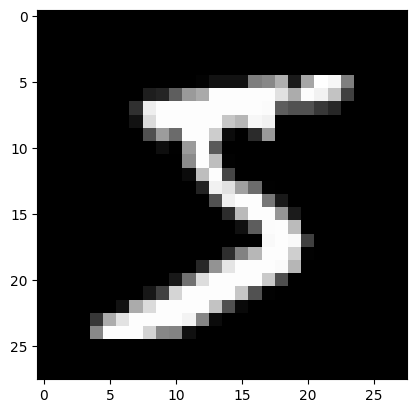

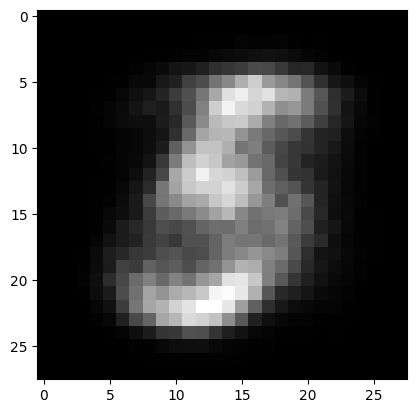

In [39]:
Image, label = next(iter(dataset))
plt.imshow(Image.squeeze(), cmap="gray")
Image = nn.Flatten()(Image).to(DEVICE)
plt.show()
with torch.inference_mode():
  y = vae(Image)[0][0].reshape(28, 28)

plt.imshow(y.cpu(),cmap="gray")
plt.show()

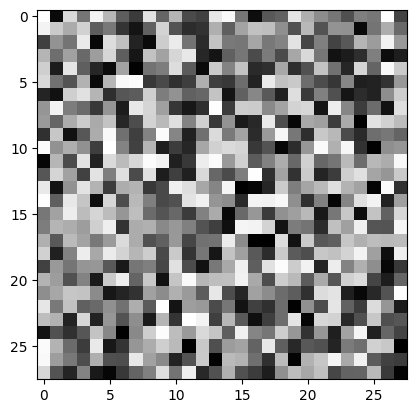

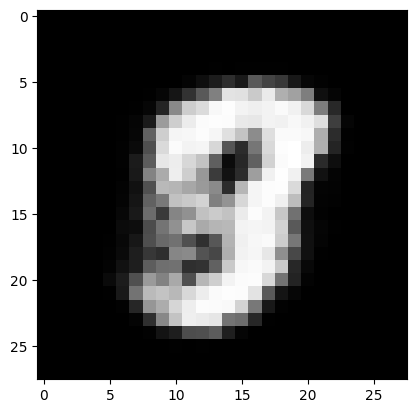

In [41]:
z = torch.rand(size=(1, 784)).to(DEVICE)
with torch.inference_mode():
  y = vae(z)[0][0].reshape(28, 28)

z = z.reshape(28, 28)
plt.imshow(z.cpu(), cmap='gray')
plt.show()
plt.imshow(y.cpu(), cmap='gray')
plt.show()

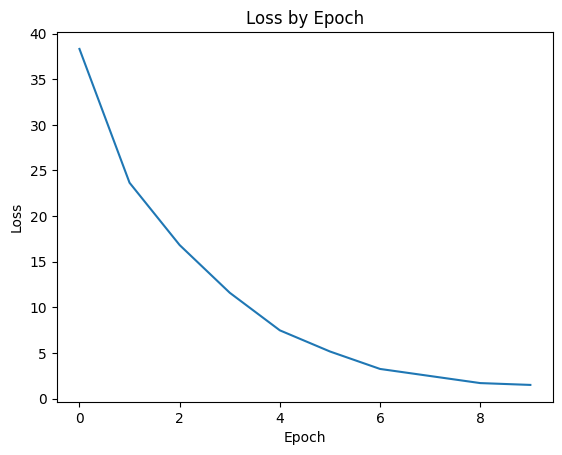

In [43]:
plt.plot(loss_list)
plt.title("Loss by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()